# 2D Transient Heat Equation in Gold (Au) under Electron-Beam Heating
---

This notebook models the 2D transient heat conduction in a **circular gold (Au) disk** (diameter = 1 um) under electron-beam irradiation. Beam and material parameters are set in cell 3.

- **Beam energy:** $E_\mathrm{beam} = 300\ \mathrm{keV}$ (monochromatic, coherent $e^-$ beam)
- **Deposited energy:** $E_P = 300 \times 0.71\% = 2.13\ \mathrm{keV}$ per incident electron
- **Current density:** $J$ — set in cell 3 (`J_Acm2`)
- **Material:** Gold (Au), circular domain diameter = 1 um

**Governing equation used in this notebook:**

$$\rho C_P \frac{\partial T}{\partial t} = k\!\left(\frac{\partial^2 T}{\partial x^2} + \frac{\partial^2 T}{\partial y^2}\right) - \frac{\varepsilon\sigma}{R_\mathrm{KO}}\!\left(T^4 - T_0^4\right) + Q_{3D}(x,y)$$

where $\rho$ is density, $C_P$ is specific heat, $k$ is thermal conductivity, $\varepsilon$ is emissivity, $\sigma$ is the Stefan-Boltzmann constant, $T_0$ is the ambient temperature, $R_\mathrm{KO}$ is the Kanaya-Okayama energy-deposition depth, and $Q_{3D}(x,y)$ is the volumetric beam-heating source.

The lumped equation

$$m C_P \frac{dT}{dt} + A\varepsilon\sigma\!\left(T^4 - T_0^4\right) = \frac{E_P I}{e_c}$$

is a separate 0D energy-balance model. It assumes a spatially uniform particle temperature and is not the PDE solved by this notebook.

---


In [1]:
# Generated by GitHub Copilot
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import j1          # Bessel function of the first kind, order 1


In [2]:
# Generated by GitHub Copilot
# ── Physical constants ────────────────────────────────────────────────────────
e_c      = 1.602176634e-19    # C       elementary charge
sigma_SB = 5.670374419e-8     # W/(m²·K⁴)  Stefan–Boltzmann
h_P      = 6.62607015e-34     # J·s     Planck constant
m_e      = 9.1093837015e-31   # kg      electron rest mass
c_light  = 2.99792458e8       # m/s     speed of light

# ── Beam parameters ───────────────────────────────────────────────────────────
E_beam_keV = 300.0                          # keV  incident beam energy (monochromatic)
E_P_keV  = E_beam_keV * 0.0071             # keV  = 300 × 0.71%  (deposited energy)
E_P_eV   = E_P_keV * 1e3                   # eV
E_P_J    = E_P_eV * e_c                    # J    = E_P in Joules
J_Acm2   = 2000.0                            # A/cm²
J_Am2    = J_Acm2 * 1e4                    # A/m²
T0       = 300.0                           # K   ambient / initial temperature

# Q = (E_P [J] · J [A/m²]) / e_c [C]  →  W/m²  (spatially uniform base flux)
Q_surf   = (E_P_J * J_Am2) / e_c

# ── Relativistic de Broglie wavelength ────────────────────────────────────────
# λ = h / √( 2 m_e E_k (1 + E_k / (2 m_e c²)) )
E_beam_J   = E_beam_keV * 1e3 * e_c        # J   kinetic energy of electrons
lambda_dB  = h_P / np.sqrt(
    2.0 * m_e * E_beam_J * (1.0 + E_beam_J / (2.0 * m_e * c_light**2))
)   # m

# ── Convergence semi-angle → Airy-disk first-zero radius ─────────────────────
alpha_conv = 8.0e-6             # rad  beam convergence semi-angle
r_airy     = 0.61 * lambda_dB / alpha_conv  # m   first dark ring (Rayleigh criterion)

# ── Gold (Au) material properties ────────────────────────────────────────────
Z_Au          = 79
A_Au_gmol     = 196.967            # g/mol
rho_Au_gcm3   =  19.32             # g/cm³
rho_Au        = rho_Au_gcm3 * 1e3  # kg/m³ = 19 320
Cp_Au         = 129.0              # J/(kg·K)
k_Au          = 317.0              # W/(m·K)
eps_Au        =   1.0              # emissivity = 1 (black body)
T_melt_Au     = 1337.0             # K   melting point
T_sublimate_Au     = 1275.0             # K   sublimation point
alpha_Au = k_Au / (rho_Au * Cp_Au) # m²/s  thermal diffusivity

print('╔══════════════════════════════════════════════════════╗')
print('║            Beam & Material Parameters                ║')
print('╠══════════════════════════════════════════════════════╣')
print(f'  E_beam = {E_beam_keV:.0f} keV  (monochromatic, coherent e⁻ beam)')
print(f'  λ_dB   = {lambda_dB*1e12:.3f} pm  (relativistic de Broglie wavelength)')
print(f'  α_conv = {alpha_conv*1e6:.1f} µrad  →  r_Airy = {r_airy*1e9:.1f} nm  (first dark ring)')
print(f'  E_P  = {E_beam_keV:.0f} × 0.71 % = {E_P_keV:.4f} keV  ({E_P_eV:.1f} eV  deposited)')
print(f'  E_P  = {E_P_J:.4e} J')
print(f'  J    = {J_Acm2:.0f} A/cm²  →  {J_Am2:.2e} A/m²')
print(f'  Q_surf = (E_P·J)/e_c = {Q_surf:.4e} W/m²')
print(f'  ρ    = {rho_Au:.0f} kg/m³')
print(f'  Cₚ   = {Cp_Au:.0f} J/(kg·K)')
print(f'  k    = {k_Au:.0f} W/(m·K)')
print(f'  ε    = {eps_Au:.1f}  (black body)')
print(f'  α    = {alpha_Au:.4e} m²/s  (thermal diffusivity)')
print(f'  T_sublimate = {T_sublimate_Au:.0f} K')
print('╚══════════════════════════════════════════════════════╝')


╔══════════════════════════════════════════════════════╗
║            Beam & Material Parameters                ║
╠══════════════════════════════════════════════════════╣
  E_beam = 300 keV  (monochromatic, coherent e⁻ beam)
  λ_dB   = 1.969 pm  (relativistic de Broglie wavelength)
  α_conv = 8.0 µrad  →  r_Airy = 150.1 nm  (first dark ring)
  E_P  = 300 × 0.71 % = 2.1300 keV  (2130.0 eV  deposited)
  E_P  = 3.4126e-16 J
  J    = 2000 A/cm²  →  2.00e+07 A/m²
  Q_surf = (E_P·J)/e_c = 4.2600e+10 W/m²
  ρ    = 19320 kg/m³
  Cₚ   = 129 J/(kg·K)
  k    = 317 W/(m·K)
  ε    = 1.0  (black body)
  α    = 1.2719e-04 m²/s  (thermal diffusivity)
  T_sublimate = 1275 K
╚══════════════════════════════════════════════════════╝


## Numerical Solution — Spatial & Temporal Temperature Distribution
---

### 0. Why "2D" but Volumetric Units [W m^-3]?

The simulation solves for $T(x,y,t)$ on a 2D grid, but the heat source and radiation loss are written in **volumetric** units [W m^-3]. This is a **depth-averaged thin-slab approximation** of the full 3D heat-transfer problem.

The real electron-beam interaction is 3D: the beam travels in the $z$ direction and deposits energy over an effective depth equal to the **Kanaya-Okayama CSDA range** $R_\mathrm{KO}$ [m]. If the temperature is approximately uniform through this thin depth, the 3D equation can be averaged over $z \in [0, R_\mathrm{KO}]$ to give a 2D in-plane model:

$$\rho C_P \frac{\partial T}{\partial t} = k\!\left(\frac{\partial^2 T}{\partial x^2}+\frac{\partial^2 T}{\partial y^2}\right) + \underbrace{\frac{Q_\mathrm{surf}}{R_\mathrm{KO}}}_{\text{W m}^{-3}} - \underbrace{\frac{\varepsilon\sigma(T^4-T_0^4)}{R_\mathrm{KO}}}_{\text{W m}^{-3}}$$

The division by $R_\mathrm{KO}$ converts surface terms into volumetric terms:

| Physical quantity | Original units | After division by $R_\mathrm{KO}$ |
|---|---|---|
| Beam surface flux $Q_\mathrm{surf} = E_P J / e_c$ | W m^-2 | W m^-3 |
| Radiation loss $\varepsilon\sigma(T^4-T_0^4)$ | W m^-2 | W m^-3 |

This makes all right-hand-side terms dimensionally consistent as [W m^-3]. Dividing by $\rho C_P$ [J m^-3 K^-1] then gives [K s^-1], the correct unit for $\partial T/\partial t$.

> **In short:** the model is 2D in space $(x,y)$, but its energy balance represents a thin 3D heated layer. $R_\mathrm{KO}$ is the effective thickness of that layer.

---

### 1. Governing PDE

$$\rho C_P \frac{\partial T}{\partial t} = k\!\left(\frac{\partial^2 T}{\partial x^2} + \frac{\partial^2 T}{\partial y^2}\right) - \frac{\varepsilon\sigma}{R_\mathrm{KO}}\!\left(T^4 - T_0^4\right) + Q_{3D}(x,y)$$

The three right-hand-side terms represent, in order: **in-plane heat diffusion**, **radiation cooling converted to a volumetric sink**, and **beam heating as a volumetric source**.

---

### 2. Spatial Distribution — the Heat Source $Q_{3D}(x,y)$

The electron beam deposits energy following a diffraction-limited **Airy-disk** intensity profile. For a coherent, monochromatic beam with convergence semi-angle $\alpha$ and electron wavenumber $k_e = 2\pi/\lambda_{dB}$:

$$I(r) \propto \left[\frac{2\,J_1(k_e\,\alpha\,r)}{k_e\,\alpha\,r}\right]^2, \qquad r = \sqrt{(x-x_c)^2+(y-y_c)^2}$$

The source is normalized so that the disk-averaged volumetric heating equals $Q_\mathrm{surf}/R_\mathrm{KO}$:

$$Q_{3D}(r) = \frac{Q_\mathrm{surf}}{R_\mathrm{KO}} \cdot \frac{I(r)}{\langle I \rangle_\mathrm{disk}}, \qquad Q_{3D} = 0 \text{ outside disk}$$

The spatial peak is at $r=0$ on the beam axis. The first dark ring occurs at $r_\mathrm{Airy} = 0.61\,\lambda_{dB}/\alpha$.

---

### 3. Temporal Evolution — Explicit FTCS Discretisation

At each time step $n \to n+1$, only grid points **inside** the circular disk are updated. Outside-disk points are reset to $T_0$ and act as non-physical padding around the circular domain:

$$T_{i,j}^{n+1} = T_{i,j}^{n} + \frac{\Delta t}{\rho C_P}\!\left[k\,\nabla^2_h T^n_{i,j} - \frac{\varepsilon\sigma}{R_\mathrm{KO}}\!\left((T^n_{i,j})^4 - T_0^4\right) + Q_{3D,i,j}\right]$$

where the five-point Laplacian is:

$$\nabla^2_h T^n_{i,j} = \frac{T^n_{i+1,j} - 2T^n_{i,j} + T^n_{i-1,j}}{\Delta x^2} + \frac{T^n_{i,j+1} - 2T^n_{i,j} + T^n_{i,j-1}}{\Delta y^2}$$

The **CFL stability limit** for explicit diffusion in 2D is:

$$\Delta t \leq \frac{\Delta x^2}{4\,\alpha}, \qquad \alpha = \frac{k}{\rho C_P}$$

A safety factor of 0.4 is applied: $\Delta t = 0.4\,\Delta x^2/(4\alpha)$.

---

### 4. Initial & Boundary Conditions

| Condition | Value |
|---|---|
| **Initial condition** | $T(x,y,0) = T_0 = 300\ \mathrm{K}$ |
| **Circular disk rim** | Outside-disk cells are reset to $T_0$ after each step |
| **Bounding-box walls** | Zero-flux ghost cells mirror the nearest interior values |

---

### 5. Characteristic Time Scale

The thermal equilibration time is set by in-plane diffusion across the disk radius:

$$\tau_\mathrm{diff} = \frac{R_\mathrm{disk}^2}{4\,\alpha} \approx \frac{(0.5\ \mu\mathrm{m})^2}{4 \times 1.27\times10^{-4}\ \mathrm{m^2/s}} \approx 0.5\ \mathrm{ns}$$

The simulation runs to $t_\mathrm{end} \approx 3\text{–}10\,\tau_\mathrm{diff}$ to capture the full rise and approach to steady state.

---


In [ ]:
# Generated by GitHub Copilot
# Spatial grid
Nx, Ny  = 100, 100
Lx = Ly = 1.0e-6                       # m, 1 um x 1 um bounding box
dx = Lx / (Nx - 1)
dy = Ly / (Ny - 1)
x  = np.linspace(0, Lx, Nx)
y  = np.linspace(0, Ly, Ny)
X, Y = np.meshgrid(x, y, indexing='ij')   # shape (Nx, Ny)

# Circular Au domain: diameter = 1 um, radius = 0.5 um
xc, yc    = Lx / 2.0, Ly / 2.0          # disk center
R_disk    = Lx / 2.0                    # m
r_xy_grid = np.sqrt((X - xc)**2 + (Y - yc)**2)
disk_mask = r_xy_grid <= R_disk         # True inside the circular domain

# Kanaya-Okayama CSDA range
# R [um] = 0.0276 * A[g/mol] * E_P[keV]^1.67 / (Z^0.89 * rho[g/cm^3])
R_KO_um = 0.0276 * A_Au_gmol * E_P_keV**1.67 / (Z_Au**0.89 * rho_Au_gcm3)
R_KO    = R_KO_um * 1e-6                # m, effective energy-deposition depth

# Airy-disk heat source for a coherent, monochromatic electron beam
# I(r) is proportional to [2*J1(k_e*alpha*r)/(k_e*alpha*r)]^2,
# where k_e = 2*pi/lambda_dB. The first dark ring is
# r_Airy = 0.61*lambda_dB/alpha_conv.
#
# Q_surf [W/m^2] is converted to Q_surf/R_KO [W/m^3], then shaped
# by the normalized Airy profile. The source is zero outside the disk.
k_e = 2.0 * np.pi / lambda_dB
arg = k_e * alpha_conv * r_xy_grid

with np.errstate(invalid='ignore', divide='ignore'):
    airy = np.where(arg < 1.0e-10, 1.0, (2.0 * j1(arg) / arg)**2)

# Normalize the Airy profile over the disk so that mean(Q3D) = Q_surf/R_KO.
mean_in_disk = airy[disk_mask].mean()
Q3D = np.where(
    disk_mask,
    (Q_surf / R_KO) * (airy / mean_in_disk),
    0.0,
)  # W/m^3

# Radiation coefficient for the volumetric sink term [W/(m^3 K^4)]
# eps*sigma*(T^4 - T0^4) [W/m^2] is divided by R_KO [m].
rad_coeff = eps_Au * sigma_SB / R_KO

n_disk = disk_mask.sum()
print(f'  Grid       : {Nx} x {Ny},  dx = {dx*1e9:.1f} nm,  circular domain diameter = {Lx*1e6:.1f} um')
print(f'  Active pts : {n_disk} / {Nx*Ny}  (inside circle)')
print(f'  CSDA depth : R_KO = {R_KO_um*1000:.3f} nm  ({R_KO*1e9:.2f} nm)')
print(f'  rad_coeff  : {rad_coeff:.3e} W/(m^3 K^4)')
print(f'  r_Airy     : {r_airy*1e9:.1f} nm  (first dark ring)')
print(f'  Q3D peak   : {Q3D.max():.3e} W/m^3   mean (disk): {Q3D[disk_mask].mean():.3e} W/m^3')


  Grid       : 100 × 100,  dx = 10.1 nm,  domain = circular  ⌀ = 1.0 µm
  Active pts : 7668 / 10000  (inside circle)
  CSDA depth : R_KO = 20.361 nm  (20.36 nm)
  rad_coeff  : 2.785e+00 W/(m³·K⁴)
  r_Airy     : 150.1 nm  (first dark ring)
  Q_2D peak  : 8.847e+19 W/m³   mean (disk): 2.092e+18 W/m³


In [ ]:
# Generated by GitHub Copilot
# Explicit FTCS time integration
# Stability limit for 2D diffusion: dt <= dx^2 / (4*alpha)
dt_crit = min(dx, dy)**2 / (4.0 * alpha_Au)
dt      = 0.4 * dt_crit               # safety factor 0.4
t_end   = 1.5e-9                      # s, 1.5 ns
N_steps = int(np.ceil(t_end / dt))
dt      = t_end / N_steps             # adjust so the last step lands exactly on t_end

# Snapshot times: 0, 0.01, 0.05, 0.1, 0.5, 1.5 ns
t_snap  = np.array([0.0, 0.01e-9, 0.05e-9, 0.1e-9, 0.5e-9, 1.5e-9])
n_snap  = set(np.round(t_snap / dt).astype(int).tolist())
snaps   = {}                          # {time_s: T_2D_array}

# Track the maximum beam-center temperature
T_max_beam = -np.inf
t_Tmax     = 0.0
snap_Tmax  = None

# Beam-center time series, sampled to limit memory use
sample_every = max(1, N_steps // 4000)
t_hist, T_hist = [], []

ic, jc = Nx // 2, Ny // 2            # beam-center grid indices

# Ghost-cell buffer for zero-flux bounding-box walls
Tp = np.empty((Nx + 2, Ny + 2))

T = np.full((Nx, Ny), T0, dtype=np.float64)   # initial condition: T = T0

print(f'  dt       = {dt:.3e} s  (stability limit: {dt_crit:.3e} s)')
print(f'  N_steps  = {N_steps:,}  (t_end = {t_end*1e9:.2f} ns)')
print('  Running solver ...')

for n in range(N_steps + 1):
    t_now = n * dt

    # Track beam-center maximum
    if T[ic, jc] >= T_max_beam:
        T_max_beam = T[ic, jc]
        t_Tmax     = t_now
        snap_Tmax  = T.copy()

    # Collect fixed snapshots and the beam-center time series
    if n in n_snap:
        snaps[t_now] = T.copy()
    if n % sample_every == 0:
        t_hist.append(t_now)
        T_hist.append(T[ic, jc])

    if n == N_steps:
        break

    # Fill ghost cells for zero-flux Neumann walls of the square bounding box.
    Tp[1:-1, 1:-1] = T
    Tp[0,   1:-1]  = T[0,  :]        # left wall, x = 0
    Tp[-1,  1:-1]  = T[-1, :]        # right wall, x = Lx
    Tp[1:-1, 0]    = T[:,  0]        # bottom wall, y = 0
    Tp[1:-1, -1]   = T[:, -1]        # top wall, y = Ly

    # Five-point finite-difference Laplacian.
    lap = (
        (Tp[2:,   1:-1] - 2.0*T + Tp[:-2,  1:-1]) / dx**2 +
        (Tp[1:-1, 2:  ] - 2.0*T + Tp[1:-1, :-2 ]) / dy**2
    )

    # Radiation cooling is active only inside the circular disk.
    rad = np.where(disk_mask, rad_coeff * (T**4 - T0**4), 0.0)

    # Forward-Euler update for the 2D depth-averaged PDE.
    T += dt * (k_Au * lap - rad + Q3D) / (rho_Au * Cp_Au)

    # Outside-disk points are non-physical padding cells and remain at ambient.
    T[~disk_mask] = T0

# Add the maximum-temperature snapshot if it does not coincide with a saved time.
if not any(abs(t_Tmax - k) < 2.0 * dt for k in snaps):
    snaps[t_Tmax] = snap_Tmax

t_hist = np.asarray(t_hist)
T_hist = np.asarray(T_hist)

print(f'  Done.')
print(f'  T (beam centre) at t_end = {T[ic, jc]:.1f} K  (T_sublimate = {T_sublimate_Au:.0f} K)')
print(f'  T_max inside disk        = {T[disk_mask].max():.1f} K')
print(f'  T_max at beam centre     = {T_max_beam:.1f} K  at t = {t_Tmax * 1e9:.4g} ns')


  dt       = 8.021e-14 s  (stability limit: 2.005e-13 s)
  N_steps  = 18,700  (t_end = 1.50 ns)
  Running solver ...
  Done.
  T (beam centre) at t_end = 320.1 K  (T_sublimate = 1275 K)
  T_max inside disk        = 320.1 K
  T_max at beam centre     = 320.1 K  at t = 1.5 ns


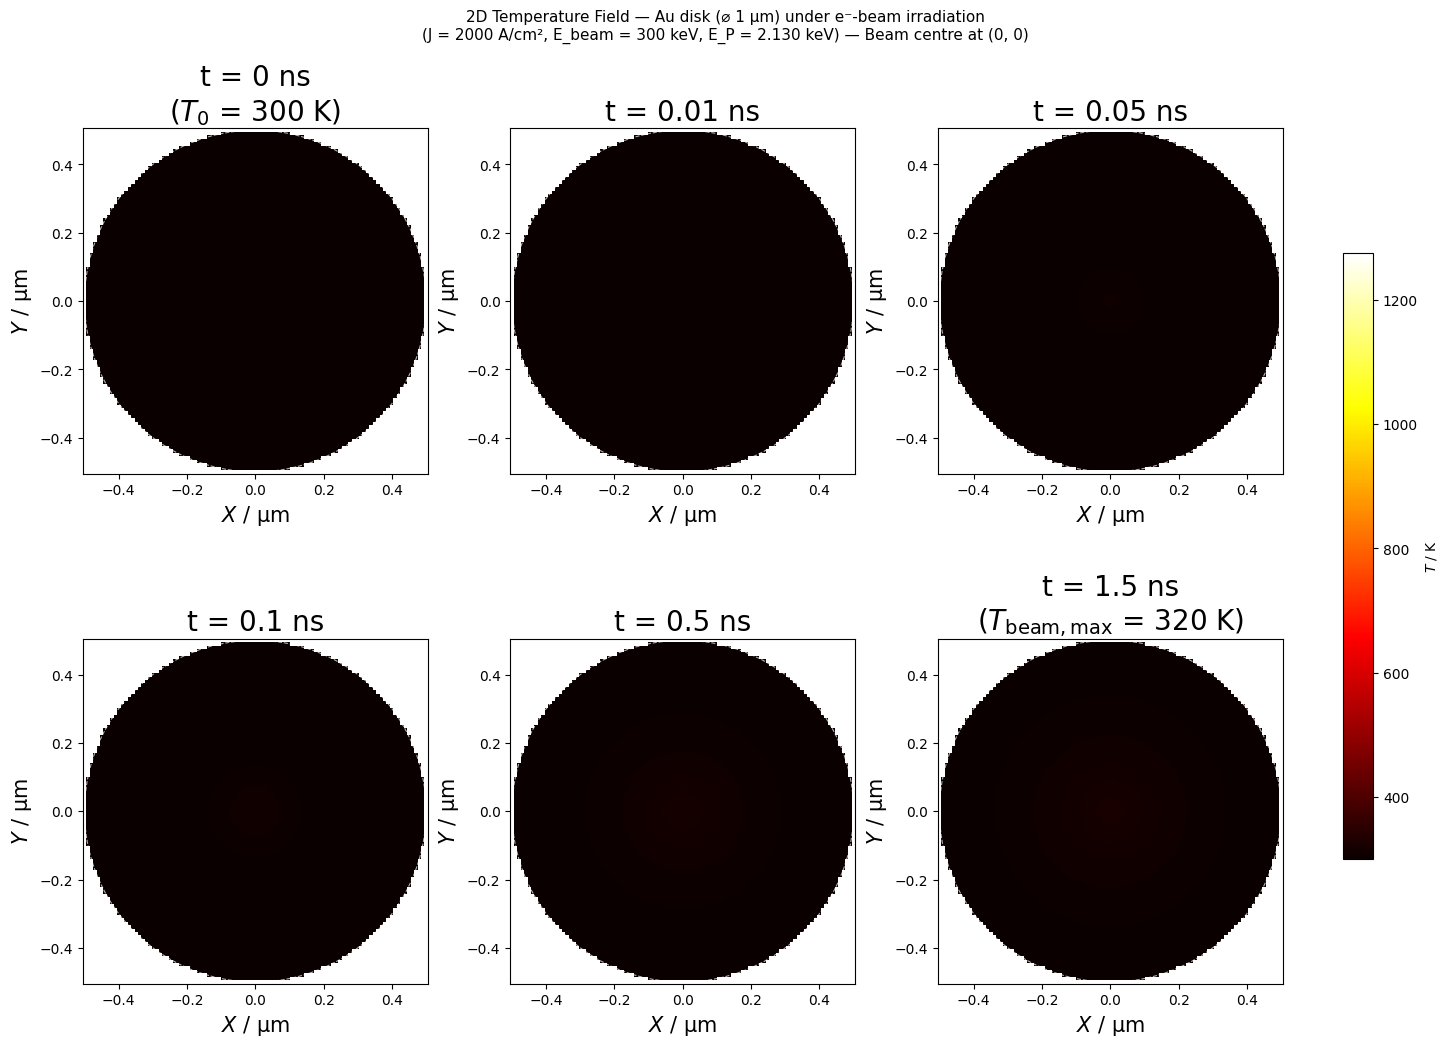

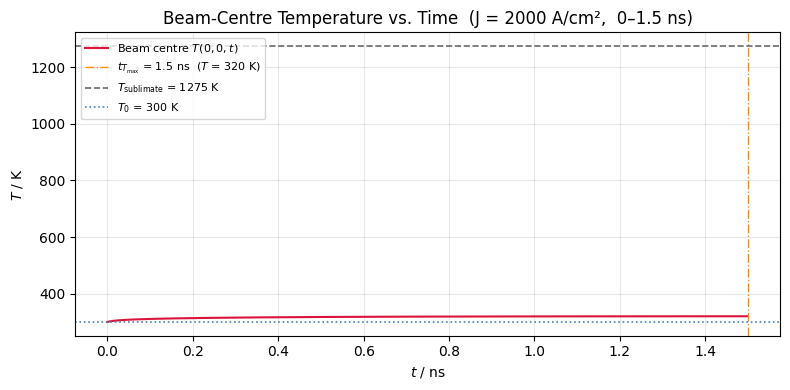

In [6]:
# Generated by GitHub Copilot
# ── Coordinate axes centred on beam (origin = beam centre) ───────────────────
x_plt = (x - xc) * 1e6               # µm  (beam centre → 0)
y_plt = (y - yc) * 1e6               # µm

# ── Circle boundary for overlay ───────────────────────────────────────────────
theta_circ = np.linspace(0, 2.0 * np.pi, 300)
circ_x = R_disk * np.cos(theta_circ) * 1e6   # µm  (centred at origin)
circ_y = R_disk * np.sin(theta_circ) * 1e6   # µm

# ── Assemble sorted snapshot list and panel labels ────────────────────────────
snap_items = sorted(snaps.items())    # [(t_s, T_array), ...] in time order
n_panels   = len(snap_items)

panel_labels = []
for t_s, _ in snap_items:
    lbl = f't = {t_s * 1e9:.2g} ns'
    if t_s == 0.0:
        lbl += f'\n($T_\\mathrm{{0}}$ = {T0:.0f} K)'
    if abs(t_s - t_Tmax) < 2.0 * dt:
        lbl += f'\n($T_\\mathrm{{beam,max}}$ = {T_max_beam:.0f} K)'
    panel_labels.append(lbl)

# ── Dynamic subplot layout ────────────────────────────────────────────────────
ncols  = min(n_panels, 3)
nrows  = int(np.ceil(n_panels / ncols))

# Colour scale: span from T0 to the in-disk maximum across all frames
T_vmax = max(T_sublimate_Au, max(arr[disk_mask].max() for _, arr in snap_items))
T_vmin = T0

# Use constrained_layout so the bottom colorbar never overlaps the panels
fig, axes = plt.subplots(nrows, ncols,
                          figsize=(4.8 * ncols, 4.8 * nrows + 1.0),
                          squeeze=False,
                          layout='constrained')
axes_flat = axes.ravel()

for idx, ((t_s, T_s), lbl) in enumerate(zip(snap_items, panel_labels)):
    ax = axes_flat[idx]
    T_plot = T_s.astype(float).copy()
    T_plot[~disk_mask] = np.nan

    im = ax.pcolormesh(
        x_plt, y_plt, T_plot.T,
        shading='auto', cmap='hot', vmin=T_vmin, vmax=T_vmax
    )
    ax.plot(circ_x, circ_y, 'w--', linewidth=0.8, alpha=0.7)   # disk boundary
    ax.set_title(lbl, fontsize=20)
    ax.set_xlabel(r'$X$ / µm', fontsize=15)
    ax.set_ylabel(r'$Y$ / µm', fontsize=15)
    ax.set_aspect('equal')

# Hide unused subplots
for ax in axes_flat[n_panels:]:
    ax.set_visible(False)

# Single shared colorbar at the bottom (constrained_layout handles spacing)
fig.colorbar(im, ax=axes_flat[:n_panels].tolist(),
             orientation='vertical', location='right',
             label=r'$T$ / K', shrink=0.6)

fig.suptitle(
    '2D Temperature Field — Au disk (⌀ 1 µm) under e⁻-beam irradiation\n'
    f'(J = {J_Acm2:.0f} A/cm², E_beam = {E_beam_keV:.0f} keV, E_P = {E_P_keV:.3f} keV) — Beam centre at (0, 0)',
    fontsize=11
)
plt.savefig('T_field_snapshots.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Plot 2: Beam-centre temperature vs time ───────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(8, 4))
ax2.plot(t_hist * 1e9, T_hist, color='crimson', linewidth=1.5,
         label='Beam centre $T(0, 0, t)$')
ax2.axvline(t_Tmax * 1e9, color='darkorange', linestyle='-.', linewidth=1.0,
            label=f'$t_{{T_\\mathrm{{max}}}}$ = {t_Tmax * 1e9:.2g} ns  ($T$ = {T_max_beam:.0f} K)')


ax2.axhline(T_sublimate_Au, color='dimgray', linestyle='--', linewidth=1.2,
            label=f'$T_\\mathrm{{sublimate}}$ = {T_sublimate_Au:.0f} K')
ax2.axhline(T0, color='steelblue', linestyle=':', linewidth=1.2,
            label=f'$T_0$ = {T0:.0f} K')
ax2.set_xlabel(r'$t$ / ns')
ax2.set_ylabel(r'$T$ / K')
ax2.set_title(f'Beam-Centre Temperature vs. Time  (J = {J_Acm2:.0f} A/cm²,  0–{t_end*1e9:.1f} ns)')

ax2.legend(loc='upper left', fontsize=8)
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('T_centre_vs_time.png', dpi=150, bbox_inches='tight')
plt.show()
